In [1]:
import os                                                                                                                                                                                                          
import pandas as pd                                                                                                                                                                                                
import numpy as np                                                                                                                                                                                                 
import matplotlib.pyplot as plt                                                                                                                                                                                    
from sklearn.tree import DecisionTreeRegressor, plot_tree                                                                                                                                                          
from sklearn.model_selection import KFold                                                                                                                                                                          
from sklearn.metrics import mean_absolute_error                                                                                                                                                                    
from sklearn.pipeline import Pipeline                                                                                                                                                                              
from sklearn.preprocessing import StandardScaler                                                                                                                                                                   
import joblib                                                                                                                                                                                                      
                                                                                                                                                                                                                    
# Library mlxtend untuk Apriori Association Rules                                                                                                                                                                  
from mlxtend.preprocessing import TransactionEncoder                                                                                                                                                               
from mlxtend.frequent_patterns import apriori, association_rules     

In [2]:
df = pd.read_csv('data.csv')                                                                                                                                                                                       
                                                                                                                                                                                                                    
print(f"Dataset berhasil dimuat. Total data: {df.shape[0]} baris, {df.shape[1]} kolom.")                                                                                                                           
print(df.head())  

Dataset berhasil dimuat. Total data: 467 baris, 5 kolom.
  ID_Transaksi        Tanggal        Nama_barang Jumlah   Satuan
0      TRX-001  2026 - 5 - 18              Telor    0.5       Kg
1      TRX-001  2026 - 5 - 18       Bawang Merah      1      Ons
2      TRX-001  2026 - 5 - 18       Bawang Putih    0.5      Ons
3      TRX-002  2026 - 5 - 18  Rokok Jarum Super      1  Bungkus
4      TRX-002  2026 - 5 - 18        Chiki Balls      2  Bungkus


In [3]:
def preprocess_data(data):                                                                                                                                                                                         
        df_prep = data.copy()                                                                                                                                                                                          
                                                                                                                                                                                                                       
        # Pastikan kolom Jumlah bertipe numerik (float) untuk mencegah penggabungan string saat agregasi                                                                                                               
        df_prep['Jumlah'] = pd.to_numeric(df_prep['Jumlah'], errors='coerce').fillna(0.0)                                                                                                                              
                                                                                                                                                                                                                       
        # 1. Konversi kolom tanggal ke tipe datetime                                                                                                                                                                   
        df_prep['tanggal'] = pd.to_datetime(df_prep['Tanggal'])                                                                                                                                                        
        df_prep['tahun'] = df_prep['tanggal'].dt.year                                                                                                                                                                  
        df_prep['bulan'] = df_prep['tanggal'].dt.month                                                                                                                                                                 
        df_prep['hari'] = df_prep['tanggal'].dt.day                                                                                                                                                                    
                                                                                                                                                                                                                       
        # 2. Hitung minggu ke-X dalam sebulan (1 s/d 5)                                                                                                                                                                
        df_prep['minggu_ke'] = ((df_prep['hari'] - 1) // 7) + 1                                                                                                                                                        
        df_prep['minggu_ke'] = df_prep['minggu_ke'].clip(1, 5)                                                                                                                                                         
                                                                                                                                                                                                                       
        # Buat mapping barang_id unik untuk pemodelan numerik                                                                                                                                                          
        unique_items = df_prep['Nama_barang'].unique()                                                                                                                                                                 
        item_to_id = {name: idx + 1 for idx, name in enumerate(unique_items)}                                                                                                                                          
        df_prep['barang_id'] = df_prep['Nama_barang'].map(item_to_id)                                                                                                                                                  
                                                                                                                                                                                                                       
        # Set harga jual dummy untuk representasi fitur                                                                                                                                                                
        df_prep['harga_jual'] = 5000                                                                                                                                                                                   
                                                                                                                                                                                                                       
        # 3. Agregasi penjualan mingguan per produk (Target: jumlah_terjual)                                                                                                                                           
        aggregated = df_prep.groupby(['tahun', 'bulan', 'minggu_ke', 'barang_id', 'harga_jual']).agg(                                                                                                                  
            jumlah_terjual=('Jumlah', 'sum')                                                                                                                                                                           
        ).reset_index()                                                                                                                                                                                                
                                                                                                                                                                                                                       
        # 4. Tambahkan Fitur Lag: penjualan_bulan_lalu                                                                                                                                                                 
        monthly_sales = df_prep.groupby(['tahun', 'bulan', 'barang_id'])['Jumlah'].sum().reset_index()                                                                                                                 
        monthly_sales.rename(columns={'Jumlah': 'penjualan_bulan_lalu'}, inplace=True)                                                                                                                                 
                                                                                                                                                                                                                       
        aggregated['tahun_lalu'] = aggregated['tahun']                                                                                                                                                                 
        aggregated['bulan_lalu'] = aggregated['bulan'] - 1                                                                                                                                                             
                                                                                                                                                                                                                       
        jan_mask = aggregated['bulan'] == 1                                                                                                                                                                            
        aggregated.loc[jan_mask, 'tahun_lalu'] = aggregated['tahun'] - 1                                                                                                                                               
        aggregated.loc[jan_mask, 'bulan_lalu'] = 12                                                                                                                                                                    
                                                                                                                                                                                                                       
        aggregated = pd.merge(                                                                                                                                                                                         
            aggregated,                                                                                                                                                                                                
            monthly_sales,                                                                                                                                                                                             
            left_on=['tahun_lalu', 'bulan_lalu', 'barang_id'],                                                                                                                                                         
            right_on=['tahun', 'bulan', 'barang_id'],                                                                                                                                                                  
            how='left',                                                                                                                                                                                                
            suffixes=('', '_temp')                                                                                                                                                                                     
        )                                                                                                                                                                                                              
                                                                                                                                                                                                                       
        aggregated.drop(columns=['tahun_temp', 'bulan_temp', 'tahun_lalu', 'bulan_lalu'], errors='ignore', inplace=True)                                                                                               
        aggregated['penjualan_bulan_lalu'] = aggregated['penjualan_bulan_lalu'].fillna(0)                                                                                                                              
        aggregated = aggregated.sort_values(by=['tahun', 'bulan', 'minggu_ke', 'barang_id']).reset_index(drop=True)                                                                                                    
                                                                                                                                                                                                                       
        features = ['barang_id', 'harga_jual', 'bulan', 'minggu_ke', 'penjualan_bulan_lalu']                                                                                                                           
        return aggregated, features                                                                                                                                                                                    
                                                                                                                                                                                                                       
dataset, features = preprocess_data(df)                                                                                                                                                                            
print(f"Data berhasil dipreproses. Jumlah dataset teragregasi: {dataset.shape[0]} baris.")                                                                                                                         
print(f"Fitur input yang digunakan: {features}")                                                                                                                                                                   
print(dataset.head())                                                                                                                                                                                              
                          

Data berhasil dipreproses. Jumlah dataset teragregasi: 196 baris.
Fitur input yang digunakan: ['barang_id', 'harga_jual', 'bulan', 'minggu_ke', 'penjualan_bulan_lalu']
   tahun  bulan  minggu_ke  barang_id  harga_jual  jumlah_terjual  \
0   2026      5          3          1        5000            1.25   
1   2026      5          3          2        5000            1.00   
2   2026      5          3          3        5000            1.50   
3   2026      5          3          4        5000           11.00   
4   2026      5          3          5        5000            3.00   

   penjualan_bulan_lalu  
0                   0.0  
1                   0.0  
2                   0.0  
3                   0.0  
4                   0.0  


In [4]:
X = dataset[features].values                                                                                                                                                                                       
y = dataset['jumlah_terjual'].values                                                                                                                                                                               
                                                                                                                                                                                                                    
# Definisikan K-Fold                                                                                                                                                                                               
kf = KFold(n_splits=5, shuffle=True, random_state=42)                                                                                                                                                              
mae_scores = []                                                                                                                                                                                                    
                                                                                                                                                                                                                    
print("=== Memulai 5-Fold Cross Validation ===")                                                                                                                                                                   
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):                                                                                                                                                      
    X_tr, X_te = X[train_idx], X[test_idx]                                                                                                                                                                         
    y_tr, y_te = y[train_idx], y[test_idx]                                                                                                                                                                         
                                                                                                                                                                                                                    
    # Definisikan Pipeline ML (StandardScaler + DecisionTreeRegressor)                                                                                                                                             
    pipeline = Pipeline([                                                                                                                                                                                          
        ('scaler', StandardScaler()),                                                                                                                                                                              
        ('regressor', DecisionTreeRegressor(max_depth=4, random_state=42))                                                                                                                                         
    ])                                                                                                                                                                                                             
                                                                                                                                                                                                                    
    # Training model                                                                                                                                                                                               
    pipeline.fit(X_tr, y_tr)                                                                                                                                                                                       
                                                                                                                                                                                                                    
    # Prediksi & Evaluasi                                                                                                                                                                                          
    preds = pipeline.predict(X_te)                                                                                                                                                                                 
    mae = mean_absolute_error(y_te, preds)                                                                                                                                                                         
    mae_scores.append(mae)                                                                                                                                                                                         
    print(f"Fold {fold} - MAE: {mae:.4f} unit laku")                                                                                                                                                               
                                                                                                                                                                                                                    
mean_mae = np.mean(mae_scores)                                                                                                                                                                                     
print(f"\nRata-rata MAE Keseluruhan: {mean_mae:.4f} unit laku")

=== Memulai 5-Fold Cross Validation ===
Fold 1 - MAE: 5.1201 unit laku
Fold 2 - MAE: 2.4625 unit laku
Fold 3 - MAE: 3.9895 unit laku
Fold 4 - MAE: 4.0057 unit laku
Fold 5 - MAE: 4.0917 unit laku

Rata-rata MAE Keseluruhan: 3.9339 unit laku


Model Pipeline akhir berhasil dilatih pada seluruh data.


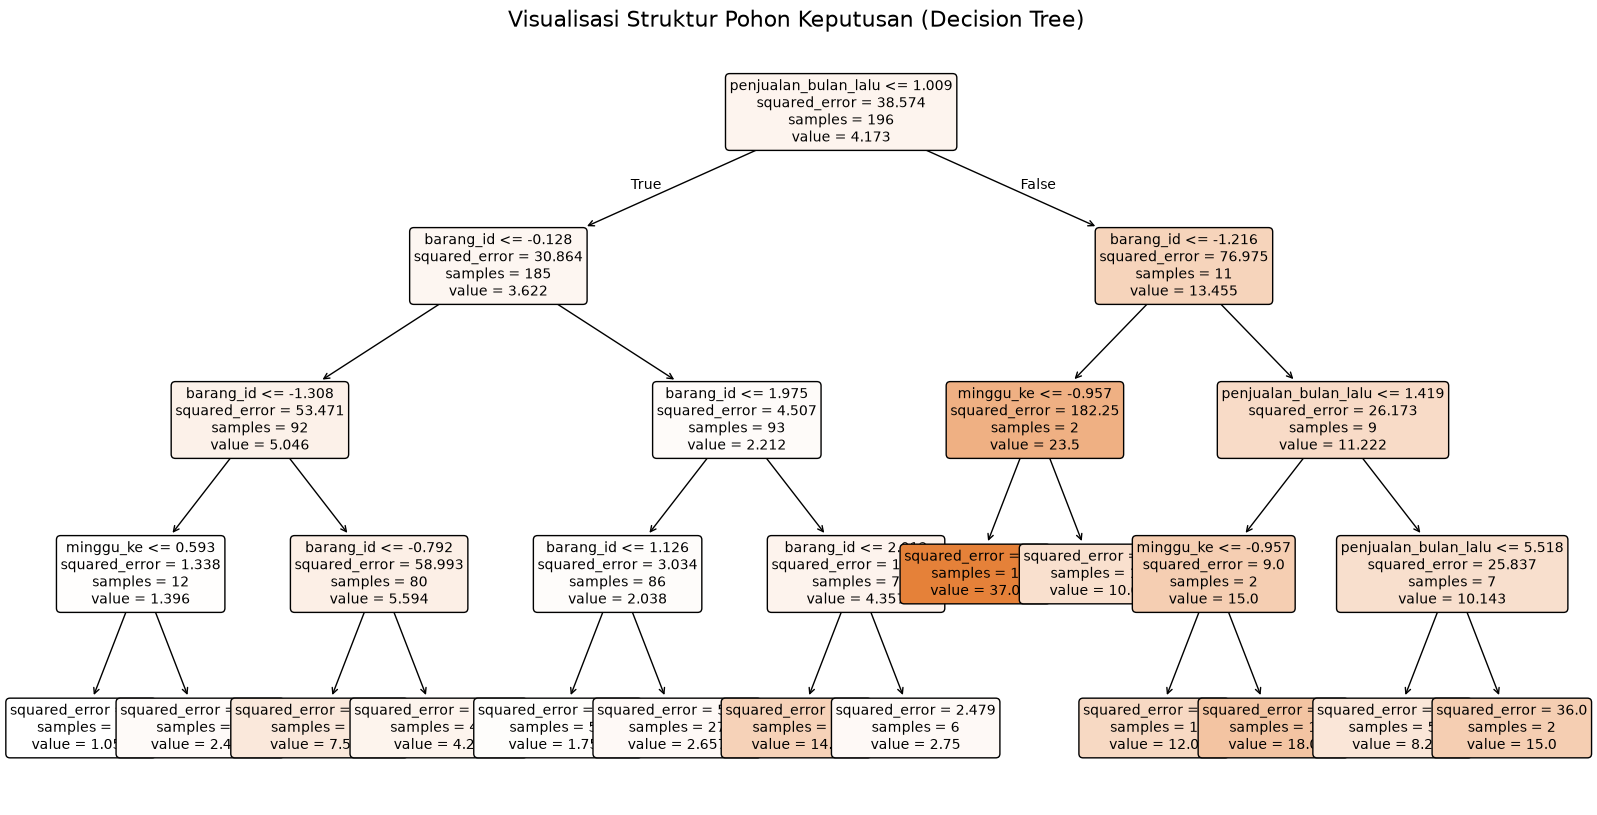

In [5]:
final_pipeline = Pipeline([                                                                                                                                                                                        
    ('scaler', StandardScaler()),                                                                                                                                                                                  
    ('regressor', DecisionTreeRegressor(max_depth=4, random_state=42))                                                                                                                                             
])                                                                                                                                                                                                                 
final_pipeline.fit(X, y)                                                                                                                                                                                           
                                                                                                                                                                                                                    
print("Model Pipeline akhir berhasil dilatih pada seluruh data.")                                                                                                                                                  
                                                                                                                                                                                                                    
# Visualisasi Struktur Pohon Keputusan (Decision Tree)                                                                                                                                                             
regressor_model = final_pipeline.named_steps['regressor']                                                                                                                                                          
plt.figure(figsize=(20, 10))                                                                                                                                                                                       
plot_tree(                                                                                                                                                                                                         
    regressor_model,                                                                                                                                                                                               
    feature_names=features,                                                                                                                                                                                        
    filled=True,                                                                                                                                                                                                   
    rounded=True,                                                                                                                                                                                                  
    fontsize=10                                                                                                                                                                                                    
)                                                                                                                                                                                                                  
plt.title("Visualisasi Struktur Pohon Keputusan (Decision Tree)", fontsize=16)                                                                                                                                     
plt.show()

In [6]:
os.makedirs('backend', exist_ok=True)                                                                                                                                                                              
model_save_path = os.path.join('backend', 'model_decision_tree.pkl')                                                                                                                                               
                                                                                                                                                                                                                    
# Persiapkan data model untuk disimpan                                                                                                                                                                             
model_data = {                                                                                                                                                                                                     
    "pipeline": final_pipeline,                                                                                                                                                                                    
    "features": features,                                                                                                                                                                                          
    "mean_mae": mean_mae,                                                                                                                                                                                          
    "data_count": len(dataset)                                                                                                                                                                                     
}                                                                                                                                                                                                                  
                                                                                                                                                                                                                    
# Simpan model                                                                                                                                                                                                     
joblib.dump(model_data, model_save_path)                                                                                                                                                                           
print(f"Sukses! Model Pipeline berhasil disimpan di: {model_save_path}") 

Sukses! Model Pipeline berhasil disimpan di: backend/model_decision_tree.pkl


In [7]:
print("=== Mempersiapkan Transaksi untuk Apriori ===")                                                                                                                                                             
# 1. Mengelompokkan produk berdasarkan ID_Transaksi                                                                                                                                                                
transactions_df = df.groupby('ID_Transaksi')['Nama_barang'].apply(list).reset_index()                                                                                                                              
transactions = transactions_df['Nama_barang'].tolist()                                                                                                                                                             
                                                                                                                                                                                                                    
print(f"Total transaksi kasir terdeteksi: {len(transactions)} keranjang.")                                                                                                                                         
print("Contoh 5 keranjang transaksi pertama:")                                                                                                                                                                     
for i, t in enumerate(transactions[:5], 1):                                                                                                                                                                        
    print(f"  Keranjang {i}: {t}")                                                                                                                                                                                 
                                                                                                                                                                                                                    
# 2. Transformasi ke bentuk Boolean (One-Hot Encoded) menggunakan mlxtend                                                                                                                                          
te = TransactionEncoder()                                                                                                                                                                                          
te_ary = te.fit(transactions).transform(transactions)                                                                                                                                                              
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)                                                                                                                                                             
                                                                                                                                                                                                                    
print(f"\nDimensi matriks biner transaksi: {df_encoded.shape[0]} baris x {df_encoded.shape[1]} produk.")                                                                                                           
print(df_encoded.head())

=== Mempersiapkan Transaksi untuk Apriori ===
Total transaksi kasir terdeteksi: 292 keranjang.
Contoh 5 keranjang transaksi pertama:
  Keranjang 1: ['Telor', 'Bawang Merah', 'Bawang Putih']
  Keranjang 2: ['Rokok Jarum Super', 'Chiki Balls']
  Keranjang 3: ['Choki Choki']
  Keranjang 4: ['Air mineral', 'Permen']
  Keranjang 5: ['Teh pucuk']

Dimensi matriks biner transaksi: 292 baris x 99 produk.
    Aida  Air Mineral  Air mineral  Amplop  Baterai  Baterai ABC  Bawang  \
0  False        False        False   False    False        False   False   
1  False        False        False   False    False        False   False   
2  False        False        False   False    False        False   False   
3  False        False         True   False    False        False   False   
4  False        False        False   False    False        False   False   

   Bawang Merah  Bawang Putih  Beng-Beng  ...  Telur  Tembakau Jangkar  \
0          True          True      False  ...  False             Fals

In [8]:
print("=== Menjalankan Algoritma Apriori ===")                                                                                                                                                                     
# 3. Mencari Frequent Itemsets (min_support = 2%)                                                                                                                                                                  
min_support = 0.02                                                                                                                                                                                                 
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)                                                                                                                                
                                                                                                                                                                                                                    
# Hitung Itemset Size (jumlah barang) dan Frequency (jumlah transaksi/support count)                                                                                                                               
frequent_itemsets['Itemset Size'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))                                                                                                                          
frequent_itemsets['Frequency'] = (frequent_itemsets['support'] * len(df_encoded)).round(0)                                                                                                                         
                                                                                                                                                                                                                    
# Duplikasi dan saring display untuk ukuran >= 2 (mempertahankan index asli)                                                                                                                                       
frequent_itemsets_display = frequent_itemsets[frequent_itemsets['Itemset Size'] >= 2].copy()                                                                                                                       
frequent_itemsets_display = frequent_itemsets_display[['support', 'itemsets', 'Itemset Size', 'Frequency']]                                                                                                        
frequent_itemsets_display.columns = ['Support', 'Itemsets', 'Itemset Size', 'Frequency']                                                                                                                           
                                                                                                                                                                                                                    
print(f"Berhasil menemukan {len(frequent_itemsets)} frequent itemsets total (tunggal + kombinasi).")                                                                                                               
print(f"Jumlah kombinasi itemset (jumlah barang >= 2): {len(frequent_itemsets_display)}.")                                                                                                                         
print("\nKombinasi Itemset Terpopuler (Itemset Size >= 2):")                                                                                                                                                       
print(frequent_itemsets_display.head(10))               

=== Menjalankan Algoritma Apriori ===
Berhasil menemukan 24 frequent itemsets total (tunggal + kombinasi).
Jumlah kombinasi itemset (jumlah barang >= 2): 5.

Kombinasi Itemset Terpopuler (Itemset Size >= 2):
     Support                                           Itemsets  Itemset Size  \
19  0.023973           frozenset({Minyak Goreng Curah, Masako})             2   
20  0.020548                frozenset({Tepung Tapioka, Masako})             2   
21  0.023973   frozenset({Minyak Goreng Curah, Tepung Tapioka})             2   
22  0.030822    frozenset({Minyak Goreng Curah, Tepung Terigu})             2   
23  0.020548  frozenset({Minyak Goreng Curah, Tepung Tapioka...             3   

    Frequency  
19        7.0  
20        6.0  
21        7.0  
22        9.0  
23        6.0  


In [ ]:
print("=== Pembentukan Aturan Asosiasi (Association Rules) ===")
# 4. Mencari aturan asosiasi berdasarkan minimal confidence 30%
# Kita menggunakan objek 'frequent_itemsets' utuh untuk menghindari KeyError
min_confidence = 0.3
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# Buat kolom Rule dengan format "BarangA, BarangB -> BarangC"
rules['Rule'] = rules['antecedents'].apply(lambda x: ', '.join(list(x))) + ' -> ' + rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Mengurutkan berdasarkan confidence tertinggi, lalu lift (mereset index untuk rules_display)
rules_display = rules.sort_values(by=['confidence', 'lift'], ascending=[False, False]).reset_index(drop=True)

# Pilih dan urutkan kolom agar pas seperti contoh tabel user
rules_display = rules_display[['Rule', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift']]
rules_display.columns = ['Rule', 'Antecedent Support', 'Consequent Support', 'Support', 'Confidence', 'Lift']

print(f"Berhasil menghasilkan {len(rules_display)} aturan asosiasi.")
print("\nAturan Asosiasi Terkuat (Top 10 Rules):")

# TAMPILKAN TABEL (Tanpa print() agar Jupyter merender tabel HTML sejajar)
rules_display.head(10)

=== Pembentukan Aturan Asosiasi (Association Rules) ===
Berhasil menghasilkan 10 aturan asosiasi.

Aturan Asosiasi Terkuat (Top 10 Rules):
                                            Rule  Antecedent Support  \
0  Tepung Tapioka, Masako -> Minyak Goreng Curah            0.020548   
1                  Masako -> Minyak Goreng Curah            0.027397   
2  Minyak Goreng Curah, Tepung Tapioka -> Masako            0.023973   
3  Minyak Goreng Curah, Masako -> Tepung Tapioka            0.023973   
4  Masako -> Minyak Goreng Curah, Tepung Tapioka            0.027397   
5                       Masako -> Tepung Tapioka            0.027397   
6          Tepung Tapioka -> Minyak Goreng Curah            0.034247   
7  Tepung Tapioka -> Minyak Goreng Curah, Masako            0.034247   
8                       Tepung Tapioka -> Masako            0.034247   
9           Tepung Terigu -> Minyak Goreng Curah            0.065068   

   Consequent Support   Support  Confidence       Lift  
0          